In [9]:
import torch
import torch_explain as te
from torch_explain import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch import nn
import matplotlib.pyplot as plt



x, c, y = datasets.xor(50000)
x_train, x_test, c_train, c_test, y_train, y_test = train_test_split(x, c, y, test_size=0.33, random_state=42)
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [13]:
class MINE(nn.Module):
    def __init__(self, x_dim, y_dim, hidden_size=256):
        super(MINE, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        return self.net(xy)


In [14]:
def mine_loss(model, x, y):
    # Positive samples: true (x, y)
    joint = model(x, y)

    # Negative samples: x with shuffled y (product of marginals)
    y_shuffled = y[torch.randperm(y.size(0))]
    marg = model(x, y_shuffled)
    marg = marg - marg.mean().detach()  # helps reduce variance
    marg = torch.log(torch.mean(torch.exp(marg)))

    # DV lower bound
    loss = - (torch.mean(joint) - torch.log(torch.mean(torch.exp(marg))))

    return loss


In [26]:
def train_MINE(
    epochs,
    model,
    optimiser,
    train_loader):
    
    mi_estimates = []
    for epoch in range(epochs):
        epoch_mi = 0
        for x_batch, y_batch in train_loader:
            loss = mine_loss(model, x_batch, y_batch)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            with torch.no_grad():
                joint= model(x_batch, y_batch)
                marg = model(x_batch, y_batch[torch.randperm(y_batch.size(0))])
            mi = torch.mean(joint) - torch.log(torch.mean(torch.exp(marg)))
            epoch_mi += mi.item()

        mi_estimates.append(epoch_mi / len(train_loader))

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: MI ≈ {mi_estimates[-1]:.4f} Nats")
    return model, mi_estimates

    
    

In [27]:
mine = MINE(x_dim=x.shape[1], y_dim=y.shape[1])
optimiser = torch.optim.AdamW(mine.parameters(), lr=0.01)
mine, mi_estimates = train_MINE(epochs=1000, model=mine, optimiser=optimiser, train_loader=train_loader)

Epoch 0: MI ≈ 0.4951
Epoch 50: MI ≈ 0.6522
Epoch 100: MI ≈ 0.6442
Epoch 150: MI ≈ 0.6355
Epoch 200: MI ≈ 0.6278
Epoch 250: MI ≈ 0.6470
Epoch 300: MI ≈ 0.6279
Epoch 350: MI ≈ 0.6405
Epoch 400: MI ≈ 0.6396
Epoch 450: MI ≈ 0.6391
Epoch 500: MI ≈ 0.6316
Epoch 550: MI ≈ 0.6293
Epoch 600: MI ≈ 0.6323
Epoch 650: MI ≈ 0.6360
Epoch 700: MI ≈ 0.6409
Epoch 750: MI ≈ 0.6387
Epoch 800: MI ≈ 0.6448
Epoch 850: MI ≈ 0.6452
Epoch 900: MI ≈ 0.6417
Epoch 950: MI ≈ 0.6340


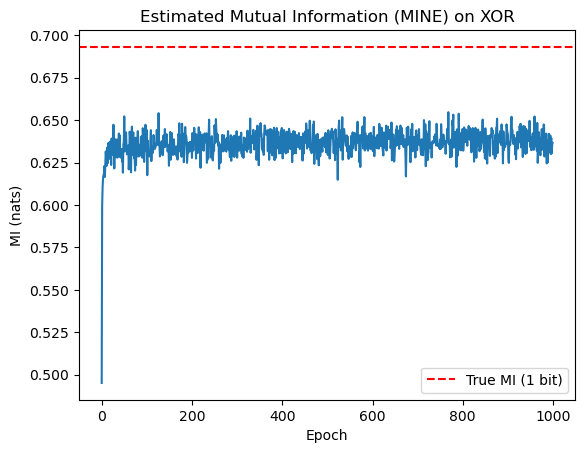

In [28]:
plt.plot(mi_estimates)
plt.axhline(y=torch.log(torch.tensor(2.0)).item(), color='r', linestyle='--', label='True MI (1 bit)')
plt.title("Estimated Mutual Information (MINE) on XOR")
plt.xlabel("Epoch")
plt.ylabel("MI (nats)")
plt.legend()
plt.show()
